# Christenson Ximenez: Parse

We import Christensons direct transcription of the original Ximenez edition.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob 
import plotly.express as px
# pd.set_option('display.max_columns', None)

In [32]:
src_id = "christenson_ximenez"
# quote_char = "’"
OHCO = ['folio_num', 'side', 'lb_num', 'para_num']

# Source to LINE

In [33]:
ct_file_name =  'christenson-transcription-MOD.txt'
ct_text = open(ct_file_name, "r").readlines()
LINE = pd.DataFrame({'line_str': ct_text})
LINE.index.name = 'line_id'
LINE.head()

,line_str
line_id,
0,Folio 1 recto\n
1,\n
2,ARE V XE OHER\n
3,Tzih varal Quiche vbi.\n
4,Varal xchicatzibah vi xchica-\n


Grab folio and side information.

In [34]:
LINE.loc[LINE.line_str.str.match("^Folio"), "folio_str"] = LINE.line_str.str.split()
LINE.folio_str = LINE.folio_str.ffill()
LINE = pd.concat([LINE, LINE.folio_str.apply(pd.Series)], axis=1)
LINE = LINE.drop(['folio_str', 0], axis=1)
LINE.columns = ['line_str', 'folio_num', 'side']
LINE.folio_num = LINE.folio_num.astype(int)
LINE

,line_str,folio_num,side
line_id,,,
0,Folio 1 recto\n,1,recto
1,\n,1,recto
2,ARE V XE OHER\n,1,recto
3,Tzih varal Quiche vbi.\n,1,recto
4,Varal xchicatzibah vi xchica-\n,1,recto
...,...,...,...
5699,mal ahauab zachinac chic. xere\n,56,verso
5700,curi mi xutzinic chi conohel qui-\n,56,verso
5701,che Sta. Cruz vbi.\n,56,verso


Remove unwanted things.

In [35]:
LINE = LINE.loc[~LINE.line_str.str.match(r"Folio \d")].copy()
# LINE.line_str = LINE.line_str.str.replace(r"\d+", "", regex=True)
LINE = LINE[~LINE.line_str.str.match("^\s*\d+\s*$")]
LINE = LINE[~(LINE.line_str == '')]
LINE = LINE[~LINE.line_str.str.match(r"^\s*$")]
# LINE.line_str = LINE.line_str.str.strip() # Prevents paragraph detection below
LINE

,line_str,folio_num,side
line_id,,,
2,ARE V XE OHER\n,1,recto
3,Tzih varal Quiche vbi.\n,1,recto
4,Varal xchicatzibah vi xchica-\n,1,recto
5,"tiquiba vi oher tzih, vticaribal,\n",1,recto
6,"vxenabal puch ronohel xban,\n",1,recto
...,...,...,...
5697,qoheic quiche ri rumal mahabi\n,56,verso
5698,"chi ilbal re, qonabe oher cu-\n",56,verso
5699,mal ahauab zachinac chic. xere\n,56,verso


Add LB numbers.

In [36]:
LINE['lb_num'] = 0
folio_num = ''
side = ''
lb_num = 0
for idx, row in LINE.iterrows():
    if row['folio_num'] != folio_num:
        folio_num = row['folio_num']
    if row['side'] != side:
        side = row['side']
        lb_num = 0
    lb_num += 1
    LINE.loc[idx, 'lb_num'] = lb_num    
LINE

,line_str,folio_num,side,lb_num
line_id,,,,
2,ARE V XE OHER\n,1,recto,1
3,Tzih varal Quiche vbi.\n,1,recto,2
4,Varal xchicatzibah vi xchica-\n,1,recto,3
5,"tiquiba vi oher tzih, vticaribal,\n",1,recto,4
6,"vxenabal puch ronohel xban,\n",1,recto,5
...,...,...,...,...
5697,qoheic quiche ri rumal mahabi\n,56,verso,32
5698,"chi ilbal re, qonabe oher cu-\n",56,verso,33
5699,mal ahauab zachinac chic. xere\n,56,verso,34


Identify paragrapghs by indent.

In [37]:
para_pat = "^    " # 4 space indent
LINE.loc[LINE.line_str.str.match(para_pat), 'para_num'] = 1
LINE.loc[LINE.line_str.str.match(para_pat), 'para_num'] = np.array(range((LINE.para_num == 1).sum())) + 1
LINE.para_num = LINE.para_num.ffill()
LINE.para_num = LINE.para_num.fillna(0)
LINE.para_num = LINE.para_num.astype(int)
LINE

,line_str,folio_num,side,lb_num,para_num
line_id,,,,,
2,ARE V XE OHER\n,1,recto,1,0
3,Tzih varal Quiche vbi.\n,1,recto,2,1
4,Varal xchicatzibah vi xchica-\n,1,recto,3,2
5,"tiquiba vi oher tzih, vticaribal,\n",1,recto,4,2
6,"vxenabal puch ronohel xban,\n",1,recto,5,2
...,...,...,...,...,...
5697,qoheic quiche ri rumal mahabi\n,56,verso,32,108
5698,"chi ilbal re, qonabe oher cu-\n",56,verso,33,108
5699,mal ahauab zachinac chic. xere\n,56,verso,34,108


Create OHCO index.

In [38]:
LINE = LINE.reset_index(drop=True).set_index(OHCO)
LINE

line_str
folio_num side  lb_num para_num                                      
1         recto 1      0                              ARE V XE OHER\n
                2      1                     Tzih varal Quiche vbi.\n
                3      2              Varal xchicatzibah vi xchica-\n
                4      2          tiquiba vi oher tzih, vticaribal,\n
                5      2                vxenabal puch ronohel xban,\n
...                                                               ...
56        verso 32     108            qoheic quiche ri rumal mahabi\n
                33     108            chi ilbal re, qonabe oher cu-\n
                34     108          mal ahauab zachinac chic.  xere\n
                35     108        curi mi xutzinic chi conohel qui-\n
                36     108                       che Sta. Cruz vbi.\n

[5257 rows x 1 columns]

Remove editorial numbers.

In [39]:
LINE.line_str = LINE.line_str.str.replace(r"\d+(\w)", r"\1", regex=True).str.replace(r"(\w)\d+", r"\1", regex=True)
LINE[LINE.line_str.str.match(r"^\d")]

line_str
folio_num side  lb_num para_num                                     
56        recto 26     97          1  Ahau εalel vnabe ahau chuva-\n
                28     98        2  Ahau ah tzic vinac hun vnim ha\n
                29     98          3  Ahau εalel camha hun vnim ha\n
                30     98                4  Nima camha hun vnim ha\n
                31     98              5  Vchuch camha hun vnim ha\n
                32     98               6  Nima camha hun vnim ha.\n
                33     98         7  Nim chocoh nihaib hun vnim ha\n
                34     98              8  Ahau auilix hun vnim ha.\n
                35     98                9  Yacolatam hun vnim ha.\n

In [40]:
LINE.line_str = LINE.line_str.str.strip()
LINE

line_str
folio_num side  lb_num para_num                                   
1         recto 1      0                             ARE V XE OHER
                2      1                    Tzih varal Quiche vbi.
                3      2             Varal xchicatzibah vi xchica-
                4      2         tiquiba vi oher tzih, vticaribal,
                5      2               vxenabal puch ronohel xban,
...                                                            ...
56        verso 32     108           qoheic quiche ri rumal mahabi
                33     108           chi ilbal re, qonabe oher cu-
                34     108         mal ahauab zachinac chic.  xere
                35     108       curi mi xutzinic chi conohel qui-
                36     108                      che Sta. Cruz vbi.

[5257 rows x 1 columns]

# LINE to PARA (DOC)

In [41]:
PARA = LINE.groupby(['para_num']).line_str.apply(" ".join).to_frame('doc_str')
PARA

,doc_str
para_num,
0,ARE V XE OHER
1,Tzih varal Quiche vbi.
2,Varal xchicatzibah vi xchica- tiquiba vi oher ...
3,"ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ..."
4,Vae cute nabe tzih nabe vch- an. mahabi oε hun...
...,...
104,unim ha. Hacavitz cut vcah ahau hun
105,vnim ha chi cahibcut nimha
106,chuvach ahau quiche


Removed hyphens, etc.

In [42]:
PARA.doc_str = PARA.doc_str\
    .str.replace(r"-\s*", "", regex=True)\
    .str.replace(r"\n", "", regex=True)\
    .str.replace(r"\s+", " ", regex=True)\
    .str.strip()
PARA

,doc_str
para_num,
0,ARE V XE OHER
1,Tzih varal Quiche vbi.
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...
3,"ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ..."
4,Vae cute nabe tzih nabe vchan. mahabi oε hun v...
...,...
104,unim ha. Hacavitz cut vcah ahau hun
105,vnim ha chi cahibcut nimha
106,chuvach ahau quiche


In [43]:
PARA['n_chars'] = PARA.doc_str.str.len()
PARA

,doc_str,n_chars
para_num,,
0,ARE V XE OHER,13
1,Tzih varal Quiche vbi.,22
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...,1215
3,"ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ...",110
4,Vae cute nabe tzih nabe vchan. mahabi oε hun v...,731
...,...,...
104,unim ha. Hacavitz cut vcah ahau hun,35
105,vnim ha chi cahibcut nimha,26
106,chuvach ahau quiche,19


# PARA to TOKEN

In [44]:
TOKEN = PARA.doc_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = PARA.index.names + ['token_num']
TOKEN

token_str
para_num token_num          
0        0               ARE
         1                 V
         2                XE
         3              OHER
1        0              Tzih
...                      ...
108      46          conohel
         47           quiche
         48             Sta.
         49             Cruz
         50             vbi.

[26903 rows x 1 columns]

In [45]:
TOKEN['term_str'] = TOKEN.token_str.str.lower()\
    .str.replace(r"[,.:;?\"'+]", "", regex=True)\
    .str.replace(r"\d+", "", regex=True)\
    .str.replace(r"[()]", "", regex=True)\
    .str.replace(r"[\[\]]", "", regex=True)
TOKEN

token_str term_str
para_num token_num                   
0        0               ARE      are
         1                 V        v
         2                XE       xe
         3              OHER     oher
1        0              Tzih     tzih
...                      ...      ...
108      46          conohel  conohel
         47           quiche   quiche
         48             Sta.      sta
         49             Cruz     cruz
         50             vbi.      vbi

[26903 rows x 2 columns]

Remove blanks.

In [46]:
TOKEN = TOKEN[TOKEN.term_str != ""].copy()

# TOKEN to VOCAB 

In [47]:
VOCAB = TOKEN.term_str.value_counts().to_frame('n').sort_index()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
a,49,0.001822,9.100126,0.016582
abah,27,0.001004,9.959948,0.010000
abanel,1,0.000037,14.714836,0.000547
abanoh,1,0.000037,14.714836,0.000547
abi,2,0.000074,13.714836,0.001020
...,...,...,...,...
εaεche,2,0.000074,13.714836,0.001020
εaεchequeleb,10,0.000372,11.392908,0.004237
εaεvachinic,1,0.000037,14.714836,0.000547


# TOKEN to CHUNK

In [48]:
n_chunks = 60
TOKEN['chunk_num'] = pd.cut([i for i in range(len(TOKEN))], n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

token_str term_str chunk_num
para_num token_num                             
0        0               ARE      are         0
         1                 V        v         0
         2                XE       xe         0
         3              OHER     oher         0
1        0              Tzih     tzih         0
...                      ...      ...       ...
108      46          conohel  conohel        59
         47           quiche   quiche        59
         48             Sta.      sta        59
         49             Cruz     cruz        59
         50             vbi.      vbi        59

[26891 rows x 3 columns]

In [49]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,are v xe oher tzih varal quiche vbi varal xchi...
1,ha chel tah chihamatah chivinaquir va vleu vla...
2,alom qaholom xevqhax cut xa quixhalatahic ruma...
3,ixim chi tzite xa chibanatahic xa pu chel apan...
4,hu ta quih hu ta quih xquec zaquiric amaquel h...


Add associated paragraph numbers to chapters.

In [50]:
CHUNK['doc_ids'] = LINE.join(TOKEN).join(CHUNK, on="chunk_num")\
    .reset_index()\
    .value_counts(['chunk_num', 'para_num'])\
    .sort_index()\
    .reset_index().groupby('chunk_num', observed=True)\
    .para_num.apply(lambda x: " ".join(map(str, x)))
CHUNK.head()

,chunk_str,doc_ids
chunk_num,,
0,are v xe oher tzih varal quiche vbi varal xchi...,0 1 2 3 4 5
1,ha chel tah chihamatah chivinaquir va vleu vla...,5 6 7
2,alom qaholom xevqhax cut xa quixhalatahic ruma...,7 8
3,ixim chi tzite xa chibanatahic xa pu chel apan...,8 9
4,hu ta quih hu ta quih xquec zaquiric amaquel h...,9 10


# TOKEN to CTM

In [51]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,a,abah,abanel,abanoh,abi,abix,abixic,abixom,ac,aca,...,εaεahv,εaεal,εaεanih,εaεaric,εaεate,εaεche,εaεchequeleb,εaεvachinic,εeε,εol
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [52]:
DP = CTM / CTM.sum()
DI = np.log2(1/DP).replace(np.inf, 0)
DH = DP * DI
VOCAB['dh'] = DH.sum()
VOCAB

,n,p,i,h,dh
term_str,,,,,
a,49,0.001822,9.100126,0.016582,4.760132
abah,27,0.001004,9.959948,0.010000,3.884155
abanel,1,0.000037,14.714836,0.000547,0.000000
abanoh,1,0.000037,14.714836,0.000547,0.000000
abi,2,0.000074,13.714836,0.001020,0.000000
...,...,...,...,...,...
εaεche,2,0.000074,13.714836,0.001020,0.000000
εaεchequeleb,10,0.000372,11.392908,0.004237,2.921928
εaεvachinic,1,0.000037,14.714836,0.000547,0.000000


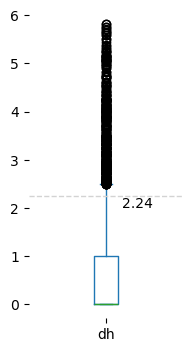

In [53]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [54]:
dh_thresh = vline

sig_mask = VOCAB.dh > dh_thresh
SIGS = VOCAB[sig_mask].index
len(VOCAB), len(SIGS)

(4992, 499)

In [55]:
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [56]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

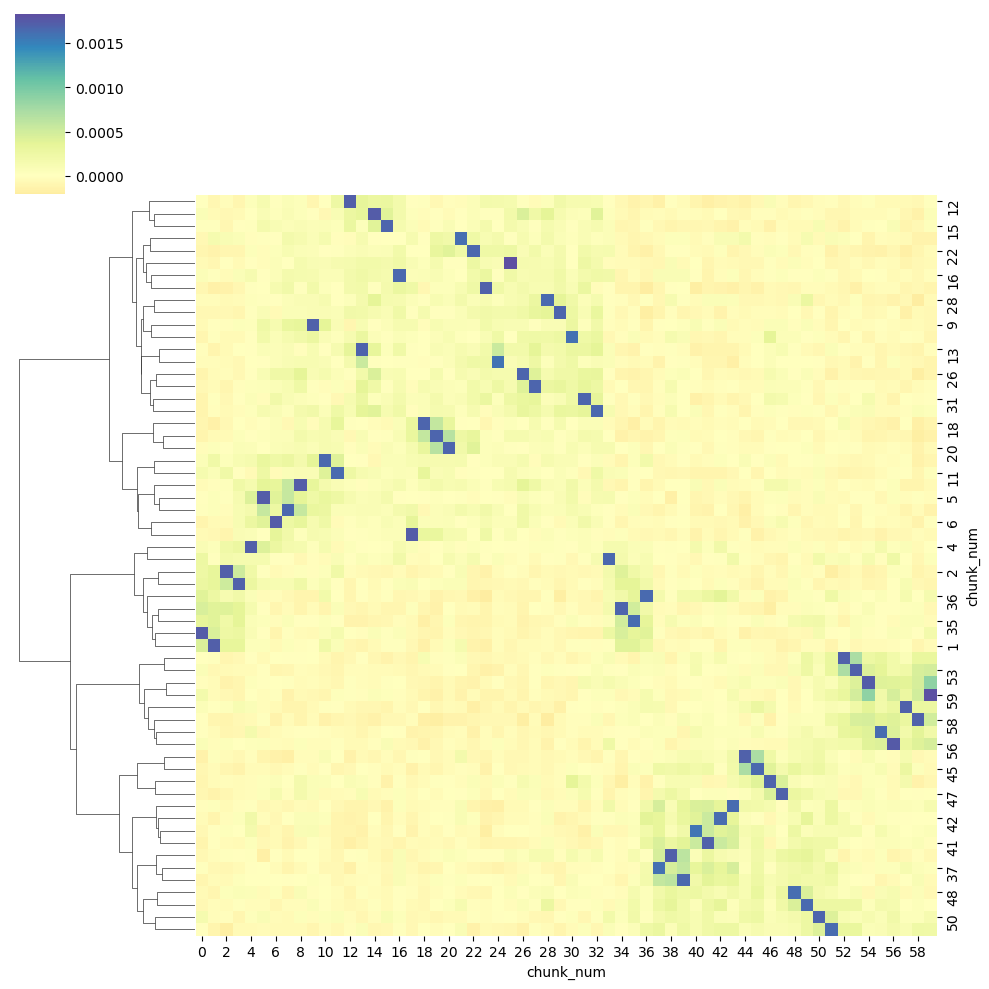

In [57]:
sns.clustermap(TFIDF_L2.T.cov(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [61]:
DOC = PARA

In [62]:
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
LINE.to_csv(f"{src_id}-LINE.csv", index=True)
DOC.to_csv(f"{src_id}-DOC.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)

In [63]:
with open(f"{src_id}-DOC_idx.txt", "w") as out:
    out.write(",".join(DOC.index.names))

# Explore character set

In [ ]:
CHAR = pd.DataFrame([list(w) for w in VOCAB.index]).stack().value_counts().to_frame('n')
CHAR.sort_index()

,n
a,4918
b,1057
c,4344
d,9
e,1425
g,1
h,3130
i,3883
j,2
k,1


# About $ε$

> The letter "ε" in the K'iche' language is pronounced by closing the throat and forcefully expelling air while keeping the tongue in the same position as for the letter "q". This produces a glottalized "q" sound.

Same as $q'$?